# SETUP: `Iceland3_MARBL_2024`

This notebook finalizes the innermost fjord-scale ROMS configuration for Iceland3_MARBL_2024.

- **Grid**: Load the 50 m Iceland3 grid built from EMOD bathymetry.
- **Tides**: Generate TPXO-based tidal forcing on the high-resolution grid.
- **Surface forcing**: Create 2023–2024 ERA5 surface forcing and a UNIFIED BGC surface climatology.
- **Rivers**: Build river forcing from the Hvalfjörður river dataset and adjust tracer values for realistic T, S, nutrients and carbon.
- **Initial conditions from Iceland2**: Interpolate a July 2024 Iceland2 restart to Iceland3.

Use this notebook when Iceland3 grid, forcings, or river setup are modified.

# Iceland3 MARBL SETUP

In [1]:
from roms_tools import Grid
import xarray as xr

In [2]:
project='/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/'
datasets='/anvil/projects/x-ees250129/Datasets/'
model_name='Iceland3'
grid_path='/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_grid.nc'

In [3]:
#%%time

#grid = Grid(
#    nx=640,
#    ny=384,
#    size_x=32,
#    size_y=19.2,
#    center_lon=-21.68,
#    center_lat=64.325,
#    rot=0,
#    mask_shapefile=datasets+"GSHHS/gshhg-shp-2.3.7/GSHHS_shp/f/GSHHS_f_L1.shp",
#    topography_source={
#        "name": "EMOD",
#        "path": datasets+"EMODnet_C2.nc"},
#    close_narrow_channels=True,
#    N=60  # number of vertical layers
#)

#filepath = project+model_name+'_grid.nc'
#grid.save(filepath)

In [5]:
grid = Grid.from_file(grid_path)

## Step 1: Tidal Forcing Creation

Builds and writes the tidal forcing file.

In [5]:
tpxo_path = datasets+"TPXO/TPXO10.v2/"
tpxo_dict = {
    "grid": tpxo_path + "grid_tpxo10v2.nc",
    "h": tpxo_path + "h_tpxo10.v2.nc",
    "u": tpxo_path + "u_tpxo10.v2.nc",
}
from roms_tools import TidalForcing
from datetime import datetime
model_reference_date = datetime(2000, 1, 1)


tidal_forcing = TidalForcing(
    grid=grid,
    source={"name": "TPXO", "path": tpxo_dict},
    ntides=15,  # Number of constituents to consider <= 15. Default is 10.
    model_reference_date=model_reference_date,  # Model reference date. Default is January 1, 2000.
    use_dask=True
)

filepath = project+model_name+"_tides.nc"
%time tidal_forcing.save(filepath)

2026-02-24 11:56:40 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_tides.nc


[########################################] | 100% Completed | 2.02 sms
CPU times: user 3.99 s, sys: 1.42 s, total: 5.41 s
Wall time: 2.19 s


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_tides.nc')]

## Step 2: Surface Forcing Creation

Builds and writes the physical surface forcing file.

In [6]:
from roms_tools import Grid, SurfaceForcing

start_time = datetime(2023, 12, 1)
end_time = datetime(2024, 12, 31)

surface_forcing_kwargs = {
    "grid": grid,
    "start_time": start_time,
    "end_time": end_time,
    "type": "physics",
    "model_reference_date": datetime(2000, 1, 1), # this is the default
}

%time

surface_forcing = SurfaceForcing(
    **surface_forcing_kwargs,
    source={"name": "ERA5"},
    use_dask=True,
)

filepath = project+model_name+"_surface_forcing2024.nc"
%time surface_forcing.save(filepath, group=True)

2026-02-24 11:56:42 - INFO - No path specified for ERA5 source; defaulting to ARCO ERA5 dataset on Google Cloud.


CPU times: user 0 ns, sys: 8 μs, total: 8 μs
Wall time: 15 μs


2026-02-24 11:59:01 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bulk_frc.opt` ROMS option file.
2026-02-24 12:11:45 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202312.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202401.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202402.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202403.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202404.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202405.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202406.nc
/anvil/projec

[########################################] | 100% Completed | 97.41 s
[########################################] | 100% Completed | 95.09 s
[########################################] | 100% Completed | 89.92 s
[########################################] | 100% Completed | 93.01 s
[########################################] | 100% Completed | 91.95 s
[########################################] | 100% Completed | 95.43 s
[########################################] | 100% Completed | 92.53 s
[########################################] | 100% Completed | 95.93 s
[########################################] | 100% Completed | 92.44 s
[########################################] | 100% Completed | 91.35 s
[########################################] | 100% Completed | 93.87 s
[########################################] | 100% Completed | 90.98 s
[########################################] | 100% Completed | 91.13 s
CPU times: user 29min 8s, sys: 5min 21s, total: 34min 29s
Wall time: 23min 30s


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202312.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202401.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202402.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202403.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202404.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202405.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202406.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_surface_forcing2024_202407.nc'),
 PosixPath('/anv

## Step 3: BGC Surface Forcing Creation

Builds and writes the biogeochemical surface forcing file.

In [7]:
%%time
unified_bgc_path = datasets+"UNIFIED/BGCdataset.nc"
unified_bgc_surface_forcing = SurfaceForcing(
    grid=grid,
    start_time=start_time,
    end_time=end_time,
    source={"name": "UNIFIED", "path": unified_bgc_path, "climatology": True},
    type="bgc",
    use_dask=True,
)

filepath = project+model_name+"_bgc_surface_forcing.nc"
%time unified_bgc_surface_forcing.save(filepath)

2026-02-24 12:35:06 - WARNING - Optional variables missing (but not critical): ['pco2_air_alt']
2026-02-24 12:35:06 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bgc.opt` ROMS option file.
2026-02-24 12:35:06 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_bgc_surface_forcing_clim.nc


[########################################] | 100% Completed | 102.41 ms
CPU times: user 188 ms, sys: 21.2 ms, total: 209 ms
Wall time: 176 ms
CPU times: user 343 ms, sys: 45.7 ms, total: 389 ms
Wall time: 655 ms


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_bgc_surface_forcing_clim.nc')]

## Step 4: River Forcing Creation

Builds and writes the river forcing file.

## Step 5: River Forcing Modification Output

Writes a modified river forcing NetCDF file.

In [8]:
from roms_tools import RiverForcing, Grid
from datetime import datetime
start_time = datetime(2024, 1, 1)
end_time = datetime(2024, 12, 31)

river_forcing = RiverForcing(
    grid=grid,
    start_time=start_time,
    end_time=end_time,
    model_reference_date=datetime(2000, 1, 1), # this is the default
    include_bgc=True,
    source = {
    "name": "DAI",
    "path": "/anvil/projects/x-ees250129/Datasets/Iceland_river_dataset/Hvalfjordur_rivers_2024.nc",
    "climatology": False
}
    
)

filepath = project+model_name+"_rivers.nc"
river_forcing.save(filepath=filepath)

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
riv=xr.open_dataset(filepath)
riv.load()

# Create new array
new_tracer = np.zeros_like(riv['river_tracer'].values)

# Temperature varies sinusoidally with time
temp = 10 * np.sin(np.linspace(0, np.pi, riv.dims['river_time']))  # 12-month cycle

# Loop through tracers
for i, tracer in enumerate(riv['tracer_name'].values):
    if tracer == 'temp':
        new_tracer[:, i, :] = temp[:, np.newaxis]  # vary with time
    elif tracer == 'salt':
        new_tracer[:, i, :] = 1
    elif tracer == 'PO4':
        new_tracer[:, i, :] = 0.4
    elif tracer == 'NO3':
        new_tracer[:, i, :] = 6
    elif tracer == 'SiO3':
        new_tracer[:, i, :] = 3
    elif tracer == 'NH4':
        new_tracer[:, i, :] = 0.4
    elif tracer == 'Fe':
        new_tracer[:, i, :] = 0.000197
    elif tracer == 'Lig':
        new_tracer[:, i, :] = 0.000465    
    elif tracer == 'O2':
        new_tracer[:, i, :] = 360    
    elif tracer == 'DIC':
        new_tracer[:, i, :] = 313    
    elif tracer == 'DIC_ALT_CO2':
        new_tracer[:, i, :] = 313  
    elif tracer == 'ALK':
        new_tracer[:, i, :] = 282 
    elif tracer == 'ALK_ALT_CO2':
        new_tracer[:, i, :] = 282 
    else:
        new_tracer[:, i, :] = 0.0
riv['river_tracer'] = (riv['river_tracer'].dims, new_tracer)

riv.to_netcdf(project+model_name+"_rivers_modified.nc")

riv['river_volume'][:] = riv['river_volume'].isel(river_time=7)*0.6

winter_months = [1, 2, 3, 4, 11, 12]

# Create a boolean mask for winter times
winter_mask = riv['abs_time'].dt.month.isin(winter_months)

# Set river_volume to zero where the mask is True
riv['river_volume'] = riv['river_volume'].where(~winter_mask, 0.0)

riv.to_netcdf(project+model_name+"_rivers_modified_new40off.nc")

2026-02-24 12:35:06 - INFO - No river indices provided. Identify all rivers within the ROMS domain and assign each of them to the nearest coastal point.
2026-02-24 12:35:07 - WARNING - No records found at or before the start_time: 2024-01-01 00:00:00.
2026-02-24 12:35:07 - WARNING - No records found at or after the end_time: 2024-12-31 00:00:00.
2026-02-24 12:35:07 - INFO - Creating 1 synthetic river(s) to handle overlapping entries.
2026-02-24 12:35:07 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_rivers.nc
/tmp/ipykernel_2322541/2026043070.py:27: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attri

In [3]:
from roms_tools import VolumeRelease
from datetime import datetime



## Step 6: Initial Conditions Creation

Builds and writes the model initial conditions file.

In [8]:
from roms_tools import Grid, InitialConditions
parent_grid = Grid.from_file('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_grid.nc')
parent_grid.update_vertical_coordinate(N=60, theta_s=5.0, theta_b=2.0, hc=300.0, verbose=False)
restart_date = datetime(2024, 3, 3, 0, 0, 0)
restart_file = project+"Iceland2_MARBL_2024_rst.20240303000000.nc"

%time


initial_conditions_from_roms = InitialConditions(
    grid=grid,
    ini_time=restart_date,
    source={"name": "ROMS", "grid": parent_grid, "path": restart_file},
    use_dask=True,
    bgc_source={
        "name": "ROMS",
        "grid": parent_grid,
        "path": restart_file,
    },
)

filepath = project+"Iceland2_initial_conditions_20240303.nc"
%time initial_conditions_from_roms.save(filepath)


CPU times: user 5 μs, sys: 1 μs, total: 6 μs
Wall time: 10.7 μs


2026-04-01 14:40:54 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland2_initial_conditions_20240303.nc


[########################################] | 100% Completed | 42.98 s
CPU times: user 28min 26s, sys: 18.6 s, total: 28min 45s
Wall time: 44.1 s


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland2_initial_conditions_20240303.nc')]

[########################################] | 100% Completed | 1.75 sms


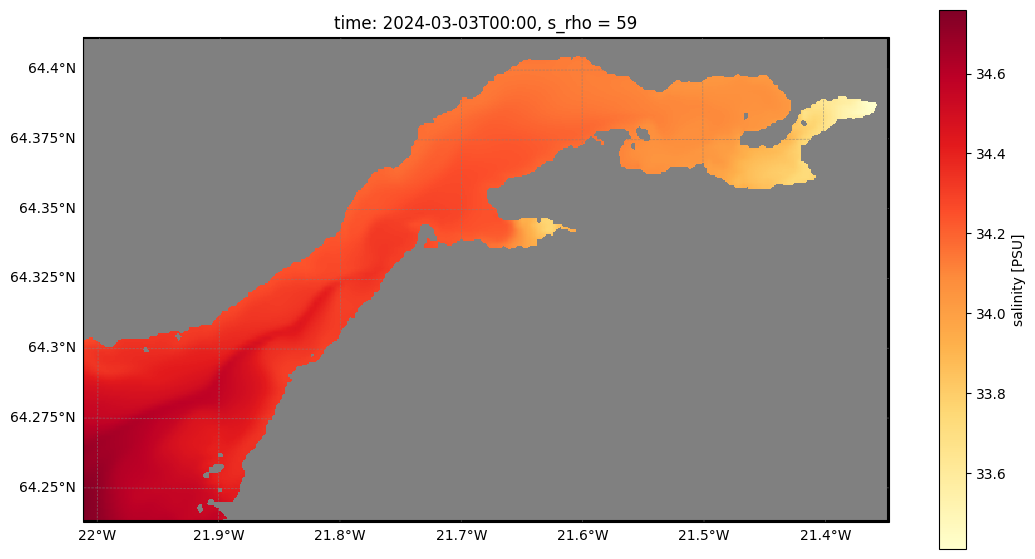

In [9]:
initial_conditions_from_roms.plot("salt", s=-1)